# California Housing Price Prediction

This notebook demonstrates a machine learning workflow to predict California housing prices. It covers data loading, exploratory data analysis (EDA), preprocessing, model training using Linear Regression, and model evaluation.

# California Housing Price Prediction

In [59]:
import pandas as pd    ## data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np     ## linear algebra

## 1. Data Loading and Initial Exploration

In [60]:
import os

# List files in the /content/ directory to help locate your uploaded file
print("Files in /content/:")
print(os.listdir('/content/'))

# You can also check specific subdirectories like /content/sample_data/
print("\nFiles in /content/sample_data/:")
print(os.listdir('/content/sample_data/'))

Files in /content/:
['.config', 'housing.csv', 'sample_data']

Files in /content/sample_data/:
['README.md', 'anscombe.json', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv', 'mnist_test.csv']


In [61]:
perth_df = pd.read_csv('/content/housing.csv')   ## Find the path of the dataset
perth_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1.1 Dataset Information and Basic Statistics

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

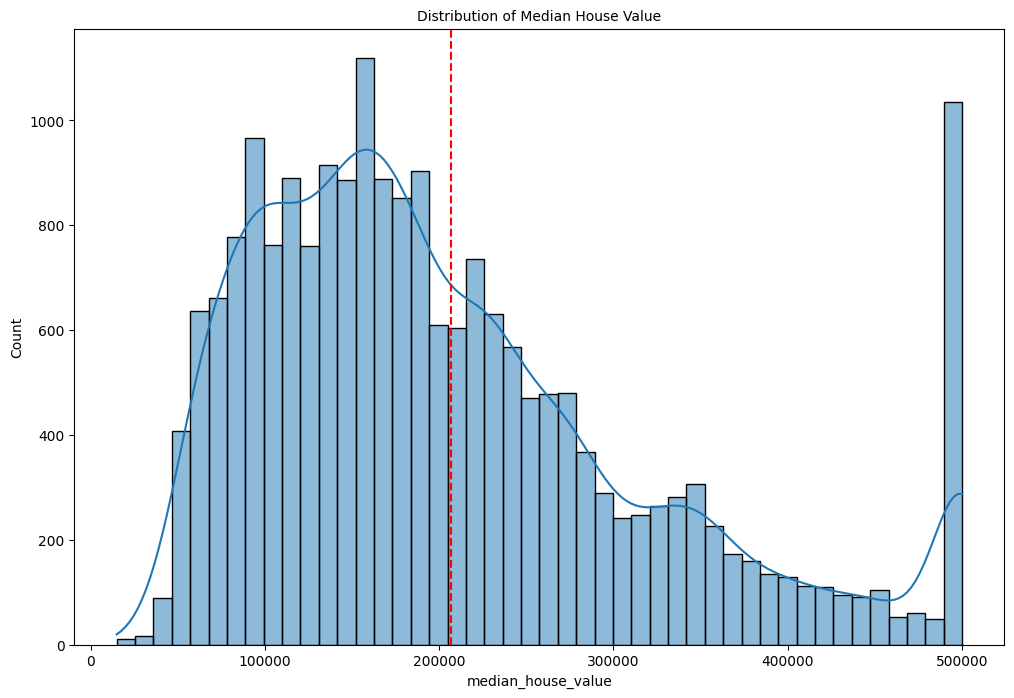

In [63]:
plt.figure(figsize=(12,8))        ## Plot Distribution of the target variable
sns.histplot(perth_df['median_house_value'], kde = True)
plt.axvline(x=perth_df['median_house_value'].mean(), color='red', linestyle='--')
plt.title("Distribution of Median House Value", fontsize=10)
plt.show()

In [64]:
print("\n Dataset Info")
perth_df.info()


 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


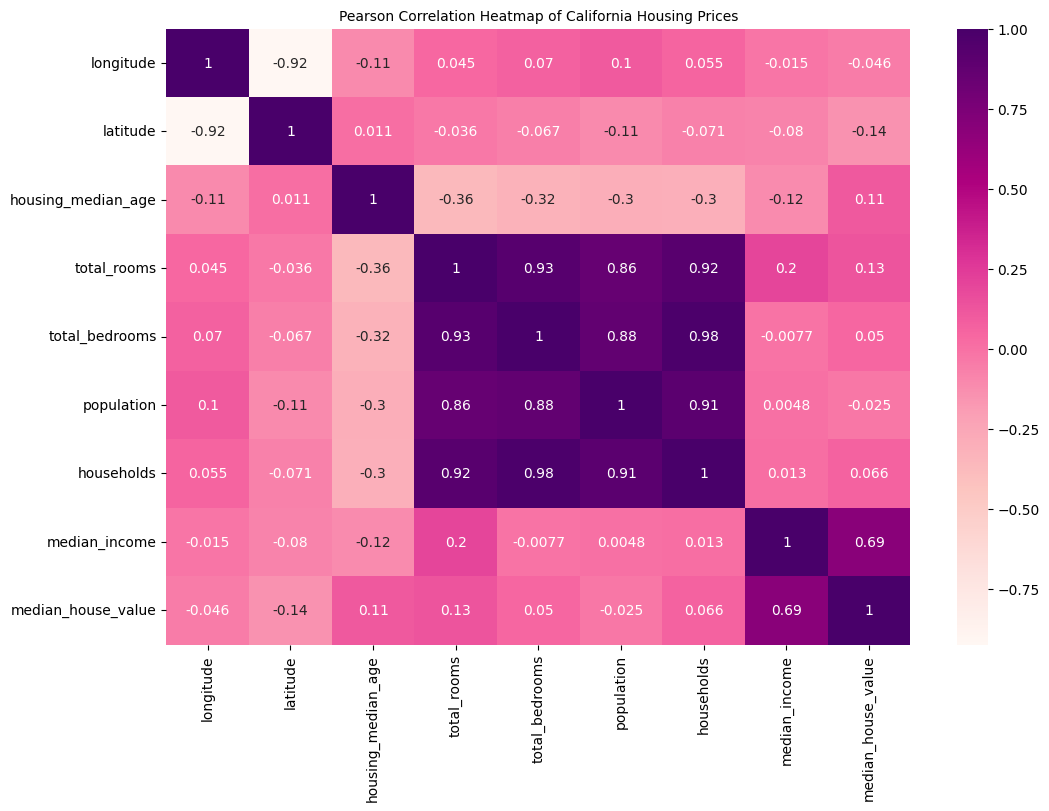

In [65]:
plt.figure(figsize = (12,8))
sns.heatmap(perth_df.select_dtypes(include=np.number).corr(method='pearson'), annot= True, cmap= 'RdPu')
plt.title("Pearson Correlation Heatmap of California Housing Prices", fontsize=10)      ### Plot correlation heatmap
plt.show()

### 1.2 Checking for Missing Values and Non-Numeric Data

In [66]:
print("\n Dataset Description")
perth_df.describe()


 Dataset Description


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [67]:
print("\n Missing Values")   ##Check for missing Values
perth_df.isnull().sum()


 Missing Values


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [68]:
non_numeric_columns = perth_df.select_dtypes(exclude=['number']).columns    ## Check for Non numeric Data
if len(non_numeric_columns)> 0:
  print("\n Non-Numeric Columns")
  print(non_numeric_columns)
else:
  print("\n No Non-Numeric Columns")


 Non-Numeric Columns
Index(['ocean_proximity'], dtype='object')


## 2. Data Preprocessing

In [69]:
from sklearn.preprocessing import LabelEncoder   ## Encode Non Numeric data to Numeric data
le = LabelEncoder()
perth_df['ocean_proximity'] = le.fit_transform(perth_df['ocean_proximity'])
perth_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [70]:
for column in ['total_bedrooms']:   # Imputing missing values with the mean for numerical columns
    if perth_df[column].isnull().any():
        perth_df[column] = perth_df[column].fillna(perth_df[column].mean())

print("Missing values after imputation:")
print(perth_df.isnull().sum())

Missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


### 2.1 Feature Scaling and Train-Test Split

In [71]:
X = perth_df.drop(['median_house_value'] ,axis =1)
y = perth_df['median_house_value']

In [72]:
#splitting data
from sklearn.preprocessing import  MinMaxScaler
Scalar = MinMaxScaler(feature_range= (0,1))

In [73]:
from sklearn.preprocessing import  MinMaxScaler
Scalar = MinMaxScaler(feature_range= (0,1))
x_scaled = Scalar.fit_transform(X)

In [74]:
from sklearn.model_selection import train_test_split ## Test Train Split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=3)

In [75]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

## 3. Model Training

In [76]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)  ## Model Fitting

LinearRegression()

In [77]:
print("Intercept : ", lr_model.intercept_) ## Making Predictions
print("Coefficients : ", lr_model.coef_)

Intercept :  365173.94594017975
Coefficients :  [-4.28031142e+05 -3.99378825e+05  6.09557602e+04 -2.65127777e+05
  5.43578085e+05 -1.38456009e+06  4.53158277e+05  5.78039215e+05
 -5.94323608e+02]


## 4. Model Prediction and Evaluation

In [78]:
y_pred = lr_model.predict(x_test)

### 4.1 Displaying Predictions

In [79]:
print(y_pred[:5])   # last 5 values

[184482.60601918  29170.02391106 195004.44711035 177342.76538044
 259771.08414129]


In [80]:
y.tail(5)

,median_house_value
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0
20639,89400.0


### 4.2 Evaluating Model Performance

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  ## Model Evaluation
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 4713198000.84
Root Mean Squared Error (RMSE): 68652.73
Mean Absolute Error (MAE): 50237.20
R-squared (R2): 0.64


In [82]:
mae = mean_absolute_error(y_test, y_pred)
mse =mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 SCORE: {r2:.2f}")

MAE: 50237.20
MSE: 4713198000.84
RMSE: 68652.73
R2 SCORE: 0.64


## 5. Conclusion

This project successfully built and evaluated a Linear Regression model for predicting California housing prices. The model achieved an R-squared score of `0.64`, explaining 64% of the variance in housing prices. The Root Mean Squared Error (RMSE) of approximately `68,652.73` indicates the average prediction error in dollars.

Further improvements could involve:
*   Feature Engineering: Creating new features from existing ones (e.g., rooms per household, population density).
*   Exploring other Regression Models: Experimenting with more advanced models like Random Forest, Gradient Boosting, or Neural Networks.
*   Hyperparameter Tuning: Optimizing model parameters for better performance.
*   More extensive EDA: Deeper insights into feature distributions and their relationships with the target variable.

This notebook provides a solid baseline for future analysis and model development.